In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom import IQAEBinom
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05
nEstim = 10000
minRatio = 2

In [3]:
pTrue = 0.2006
thetaTrue = np.arcsin(np.sqrt(pTrue))

In [4]:
with open('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/results_IQAE_pTrue0.2006_epsilon0001_alpha005.dat', 'rb') as f:
    results = pickle.load(f)

(array([   0.,    0.,    0.,    0.,   35.,  163.,  791., 1165., 1270.,
         800.,  637.,  285.,  269.,  210.,  176.,  224.,  260.,  267.,
         253.,  426.,  449.,  444.,  358.,  302.,  310.,  304.,  122.,
         164.,   37.,   32.,   34.,   26.,   13.,    7.,    6.,    8.,
           6.,   10.,    8.,    5.,   10.,   10.,    3.,    5.,   26.,
           4.,   18.,    7.,    7.,   19.,   12.,    3.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.]),
 array([100., 110., 120., 130., 140., 150., 160., 170., 180., 190., 200.,
        210., 220., 230., 240., 250., 260., 270., 280., 290., 300., 310.,
        320., 330., 340., 350., 360., 370., 380., 390., 400., 410., 420.,
        430., 440., 450., 460., 470., 480., 490., 500., 510., 520., 530.,
        540., 550., 560., 570., 580., 590., 600., 610., 620., 630., 640.,
        650., 660., 670., 680., 690., 700.]),
 <BarContainer object of 60 artists>)

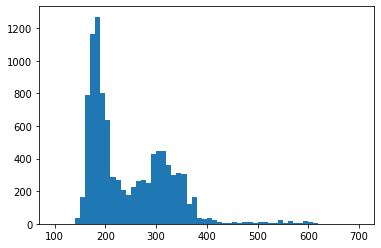

In [5]:
plt.hist([r["nGrover"][-1] for r in results], range=(100,700), bins=60)

In [6]:
# 次のroundに行く場合はNaNとする
nGrovers = np.arange(130, 621, 10)
numAng = 40
angleFracs = np.arange(1 / numAng / 2, 1, 1 / numAng)
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2)
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)
        resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.2006.csv", index=False)

130 0.0125 2023-11-07 20:02:47.507851


<ipython-input-6-0b0e9b38bc82>:25: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


130 0.037500000000000006 2023-11-07 20:02:51.697259
130 0.06250000000000001 2023-11-07 20:02:56.418643
130 0.08750000000000001 2023-11-07 20:03:00.743042
130 0.11250000000000002 2023-11-07 20:03:05.365774
130 0.13750000000000004 2023-11-07 20:03:11.169930
130 0.16250000000000003 2023-11-07 20:03:18.882955
130 0.18750000000000006 2023-11-07 20:03:27.452429
130 0.21250000000000005 2023-11-07 20:03:35.131164
130 0.23750000000000004 2023-11-07 20:03:42.000896
130 0.26250000000000007 2023-11-07 20:03:48.428320
130 0.2875000000000001 2023-11-07 20:03:54.848077
130 0.31250000000000006 2023-11-07 20:04:01.769015
130 0.3375000000000001 2023-11-07 20:04:09.871778
130 0.3625000000000001 2023-11-07 20:04:19.689994
130 0.38750000000000007 2023-11-07 20:04:29.592923
130 0.4125000000000001 2023-11-07 20:04:37.358467
130 0.4375000000000001 2023-11-07 20:04:43.486186
130 0.4625000000000001 2023-11-07 20:04:48.662705
130 0.4875000000000001 2023-11-07 20:04:53.351461
130 0.5125000000000001 2023-11-07 20:

In [7]:
resDf

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,130.0,38.0,0.0125,NaN,10000.0,0.0
1,130.0,38.0,0.0375,NaN,10000.0,0.0
2,130.0,38.0,0.0625,NaN,10000.0,0.0
3,130.0,38.0,0.0875,NaN,10000.0,0.0
4,130.0,38.0,0.1125,NaN,10000.0,0.0
...,...,...,...,...,...,...
1995,620.0,183.0,0.8875,0.000110,10000.0,10000.0
1996,620.0,183.0,0.9125,0.000100,10000.0,10000.0
1997,620.0,183.0,0.9375,0.000085,10000.0,10000.0
1998,620.0,183.0,0.9625,0.000061,10000.0,10000.0


In [8]:
resDf["Bias"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
1995    0.000110
1996    0.000100
1997    0.000085
1998    0.000061
1999    0.000023
Name: Bias, Length: 2000, dtype: float64

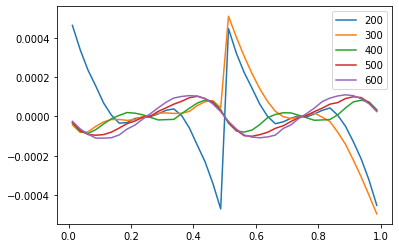

In [9]:
ax = plt.gca()
for nG in [200, 300, 400, 500, 600]:
    resDfPart = resDf[resDf["nGrover"] == nG]
    plt.plot(resDfPart["AngleFrac"], resDfPart["Bias"], label=str(nG))
plt.legend()
plt.show()

In [10]:
nGroversExp = np.array([r["nGrover"][-1] for r in results])
angleFracExp = np.modf((2 * nGroversExp + 1) * thetaTrue / np.pi)[0]

In [11]:
np.unique(nGroversExp, return_counts=True)

(array([146, 149, 151, 152, 153, 154, 156, 158, 159, 161, 163, 164, 165,
        166, 168, 169, 170, 171, 173, 174, 175, 176, 178, 179, 180, 181,
        183, 185, 186, 187, 188, 190, 191, 192, 193, 195, 196, 197, 198,
        200, 201, 202, 203, 205, 206, 207, 208, 209, 210, 212, 213, 214,
        215, 217, 218, 219, 220, 222, 224, 225, 227, 229, 230, 232, 233,
        234, 235, 236, 237, 239, 240, 241, 242, 244, 245, 246, 247, 249,
        251, 252, 254, 256, 257, 258, 259, 261, 262, 263, 264, 266, 267,
        268, 269, 271, 272, 273, 274, 276, 277, 278, 279, 281, 283, 284,
        285, 286, 288, 289, 290, 291, 293, 294, 295, 296, 298, 299, 300,
        301, 302, 303, 304, 305, 306, 307, 308, 310, 311, 312, 313, 314,
        315, 317, 318, 319, 320, 321, 322, 323, 324, 325, 327, 328, 329,
        330, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343,
        344, 345, 346, 347, 349, 350, 351, 352, 353, 354, 355, 356, 357,
        359, 361, 362, 364, 365, 366, 367, 368, 369

In [12]:
# End num 少なすぎるところはNaNに
resDf_RemoveSmallNum = resDf.copy()
resDf_RemoveSmallNum["Bias"] = np.where(resDf_RemoveSmallNum["NumEnd"] < 1000, np.nan, resDf_RemoveSmallNum["Bias"])
biasMat = np.reshape(np.array(resDf_RemoveSmallNum["Bias"]), (len(nGrovers), len(angleFracs))).T

In [13]:
# matrixを補間
nGsInterp = np.arange(130, 621)

biasMatInterp = np.zeros((len(angleFracs), len(nGsInterp)))

for ingInterp in range(len(nGsInterp)):
    nGInterp = nGsInterp[ingInterp]
    ingOrg = np.abs(nGrovers - nGInterp).argmin()
    biasMatInterp[:,ingInterp] = biasMat[:,ingOrg]

In [14]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

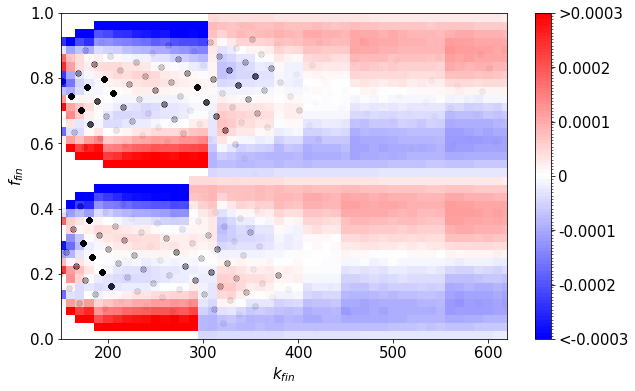

In [16]:
fig, ax = plt.subplots(figsize=(10,6))
levels = MaxNLocator(nbins=100).tick_values(-0.0003, 0.0003)
cmap = plt.colormaps['bwr']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
heatmap = ax.pcolor(nGsInterp, angleFracs, biasMatInterp, cmap="bwr", norm=norm)
cbar = fig.colorbar(heatmap, ax=ax) # カラーバー

ticks  = np.arange(-0.0003, 0.00031, 0.0001)
labels = ['<-0.0003', '-0.0002', '-0.0001', '0', '0.0001', '0.0002', '>0.0003']
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)
cbar.ax.tick_params(axis='y', labelsize=15)

ax.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)
ax.set_ylim(0,1)
ax.set_xlim(150,620)
ax.set_xlabel("$k_{fin}$", fontsize=15)
ax.set_ylabel("$f_{fin}$", fontsize=15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

# plt.savefig("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230914_Bias_VariousNGrovAngleFrac/BiasHeatmap&NGrovFracAngleScatter_p0.2.png")
# plt.show()